In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
# read chibio
m = pd.read_csv('data/pOXA48/chibio.tsv.gz', sep='\t')
# round time
m['time'] = [round(float(x), 2) for x in m['time']]
# read plate counts
c = pd.read_csv('data/pOXA48/plate_counts.tsv', sep='\t')
# round time
c['time'] = [round(float(x), 2) for x in c['time']]
# take the log of the CFU/mL
c['log_CFU/mL'] = np.log10(c['CFU/mL'])
# only KAN plates
c = c[c['plate'] == 'KAN']
# read plate reader fluorescence
p = pd.read_csv('data/pOXA48/plate_reader_fluorescence.tsv', sep='\t')
# round time
p['time'] = [round(float(x), 2) for x in p['time']]
# take the log of the emission
p['log_emission'] = np.log10(p['emission'])
# read flow cytometer
f = pd.read_csv('data/pOXA48/flow_cytometer.tsv', sep='\t')
# round time
f['time'] = [round(float(x), 2) for x in f['time']]

In [4]:
# cut data from earlier than 36 hours
# for chibio take the average over the time period
m = m[m['time'] >= 36].reset_index(drop=True)
m = m.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])[['smooth_masked_FP1_emit1', 'smooth_masked_FP2_emit1']].mean()
c = c[c['time'] >= 36].reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
p = p[p['time'] >= 36].reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
f = f[f['time'] >= 36].reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])

In [5]:
# chibio vs plate counting
o = m.join(c, 
           how='inner').reset_index()

o = o.groupby(['vial', 'replicate', 'name', 'short',
               'plasmid', 'drug', 'plate', 'strain'])[
    ['smooth_masked_FP1_emit1', 'smooth_masked_FP2_emit1',
     'log_CFU/mL']].corr().reset_index().rename(
        columns={'level_8': 'variable'})

res = []
tmp = o[(o['strain'] == 'PL') & (o['variable'] == 'smooth_masked_FP1_emit1')].copy()
tmp['member'] = 'PL'
res.append(tmp)
tmp = o[(o['strain'] == 'PM') & (o['variable'] == 'smooth_masked_FP2_emit1')].copy()
tmp['member'] = 'PM'
res.append(tmp)
o = pd.concat(res).reset_index(drop=True)

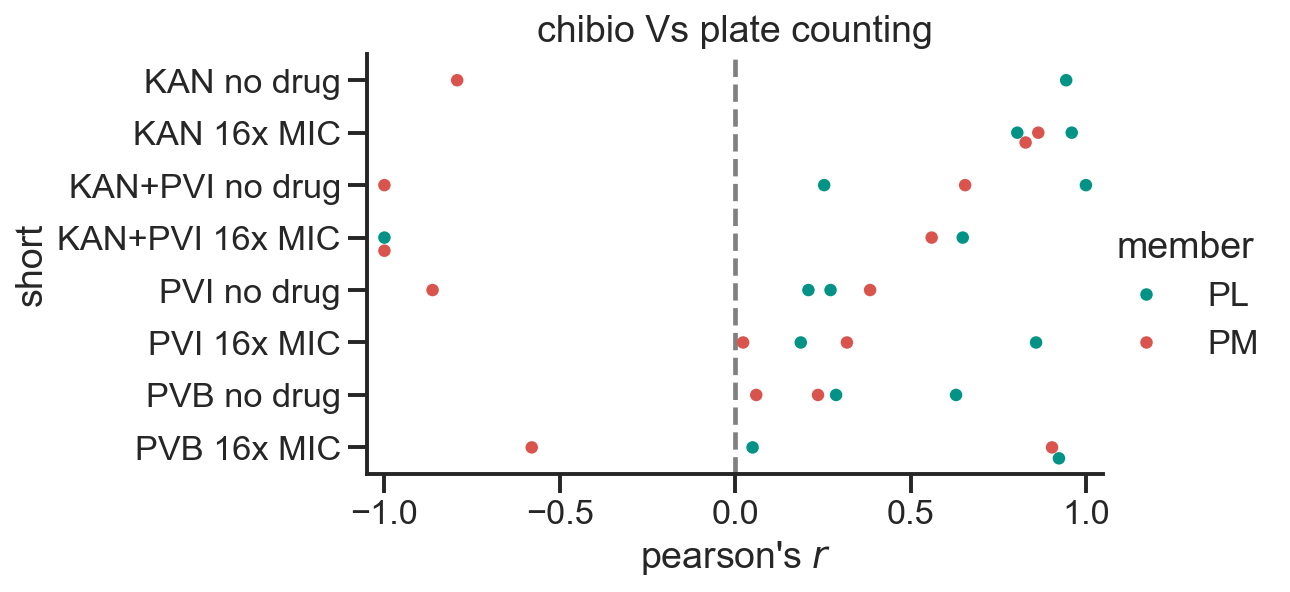

In [6]:
cp = sns.catplot(data=o,
                 hue='member',
                 kind='swarm',
                 # dodge=True,
                 palette=['xkcd:teal',
                          'xkcd:pale red'],
                 y='short',
                 x='log_CFU/mL',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='chibio Vs plate counting',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')

In [7]:
# chibio vs plate reader
o = m.join(p, 
           how='inner').reset_index()

o = o.groupby(['vial', 'replicate', 'name', 'short',
               'plasmid', 'drug', 'wavelength'])[
    ['smooth_masked_FP1_emit1', 'smooth_masked_FP2_emit1',
     'log_emission']].corr().reset_index().rename(
        columns={'level_7': 'variable'})

res = []
tmp = o[(o['wavelength'] == '467-510') & (o['variable'] == 'smooth_masked_FP1_emit1')].copy()
tmp['member'] = 'PL'
res.append(tmp)
tmp = o[(o['wavelength'] == '523-620') & (o['variable'] == 'smooth_masked_FP2_emit1')].copy()
tmp['member'] = 'PM'
res.append(tmp)
o = pd.concat(res).reset_index(drop=True)

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


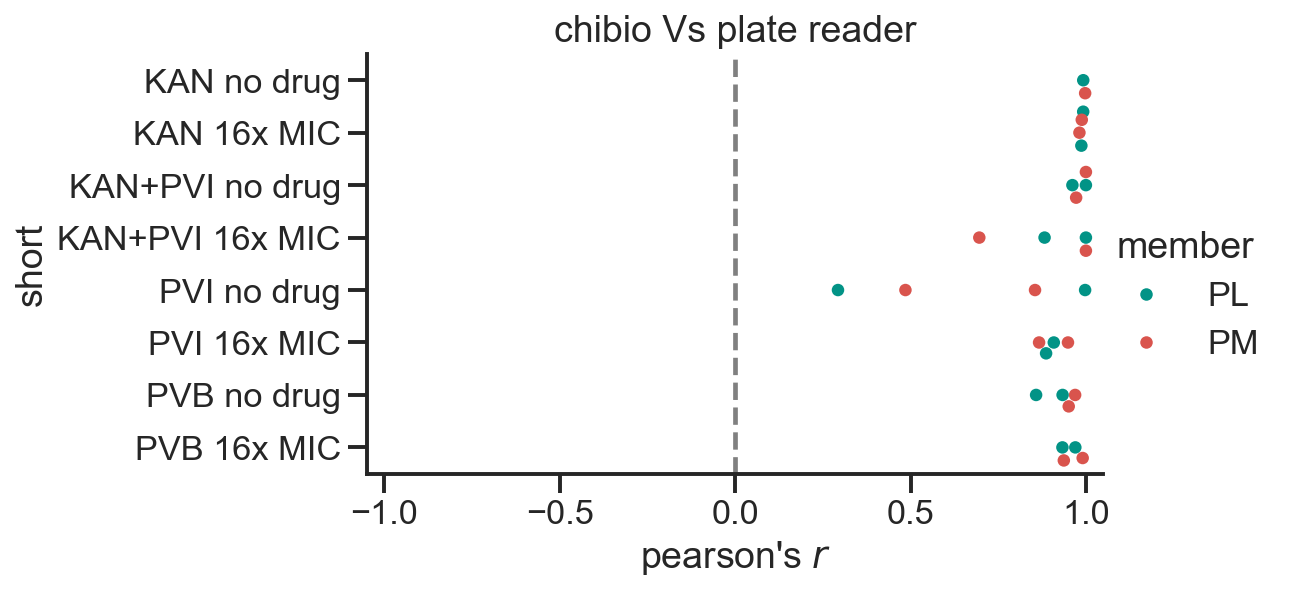

In [8]:
cp = sns.catplot(data=o,
                 hue='member',
                 kind='swarm',
                 # dodge=True,
                 palette=['xkcd:teal',
                          'xkcd:pale red'],
                 y='short',
                 x='log_emission',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='chibio Vs plate reader',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')

In [9]:
# chibio vs flow
o = m.join(f, 
           how='inner').reset_index()

o = o.groupby(['vial', 'replicate', 'name', 'short',
               'plasmid', 'drug', 'strain'])[
    ['smooth_masked_FP1_emit1', 'smooth_masked_FP2_emit1',
     'log10(events)', 'proportion']].corr().reset_index().rename(
        columns={'level_7': 'variable'})

res = []
tmp = o[(o['strain'] == 'PL') & (o['variable'] == 'smooth_masked_FP1_emit1')].copy()
tmp['member'] = 'PL'
res.append(tmp)
tmp = o[(o['strain'] == 'PM') & (o['variable'] == 'smooth_masked_FP2_emit1')].copy()
tmp['member'] = 'PM'
res.append(tmp)
o = pd.concat(res).reset_index(drop=True)

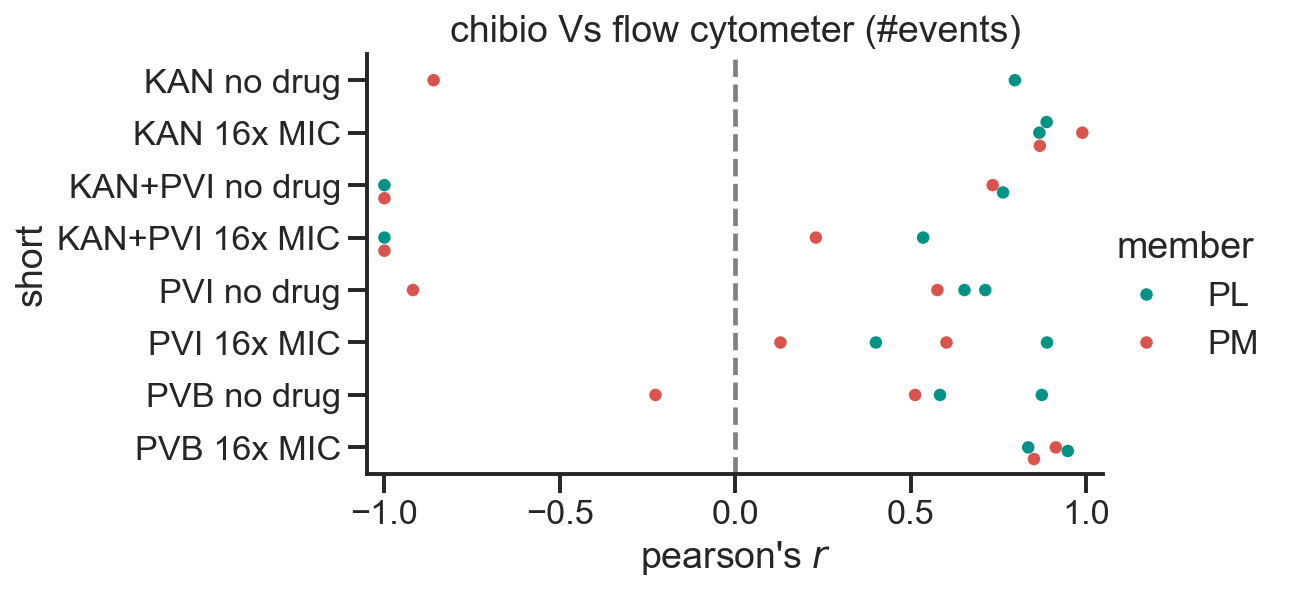

In [10]:
cp = sns.catplot(data=o,
                 hue='member',
                 kind='swarm',
                 # dodge=True,
                 palette=['xkcd:teal',
                          'xkcd:pale red'],
                 y='short',
                 x='log10(events)',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='chibio Vs flow cytometer (#events)',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')

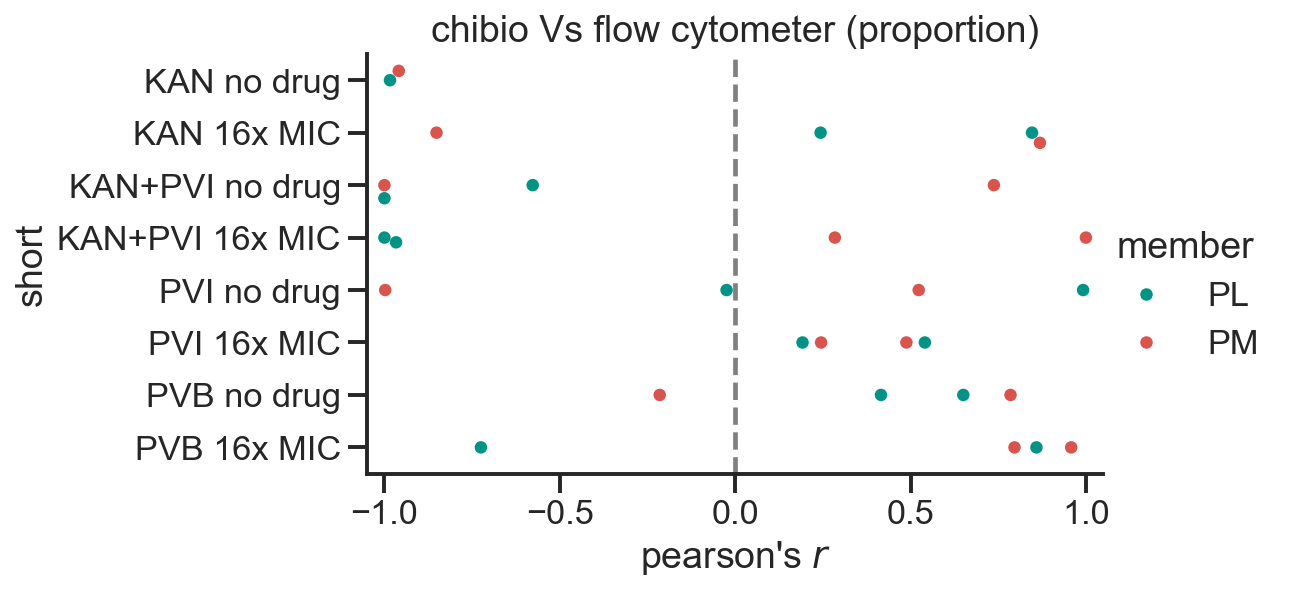

In [11]:
cp = sns.catplot(data=o,
                 hue='member',
                 kind='swarm',
                 # dodge=True,
                 palette=['xkcd:teal',
                          'xkcd:pale red'],
                 y='short',
                 x='proportion',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='chibio Vs flow cytometer (proportion)',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')

In [12]:
# counting vs flow
c = c.reset_index().set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'strain', 'time'])
f = f.reset_index().set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'strain', 'time'])
o = c.join(f, 
           how='inner').reset_index()

o = o.groupby(['vial', 'replicate', 'name', 'short',
               'plasmid', 'drug', 'strain'])[
    ['log_CFU/mL',
     'log10(events)', 'proportion']].corr().reset_index().rename(
        columns={'level_7': 'variable'})

res = []
tmp = o[(o['strain'] == 'PL') & (o['variable'] == 'log_CFU/mL')].copy()
tmp['member'] = 'PL'
res.append(tmp)
tmp = o[(o['strain'] == 'PM') & (o['variable'] == 'log_CFU/mL')].copy()
tmp['member'] = 'PM'
res.append(tmp)
o = pd.concat(res).reset_index(drop=True)

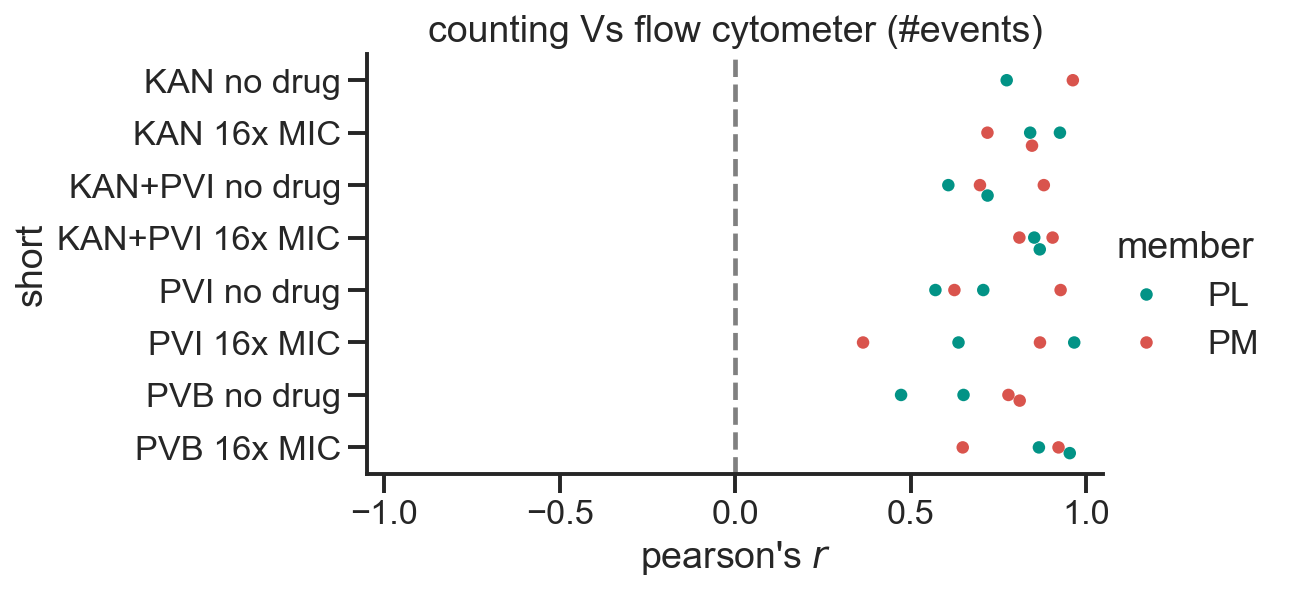

In [13]:
cp = sns.catplot(data=o,
                 hue='member',
                 kind='swarm',
                 # dodge=True,
                 palette=['xkcd:teal',
                          'xkcd:pale red'],
                 y='short',
                 x='log10(events)',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='counting Vs flow cytometer (#events)',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')

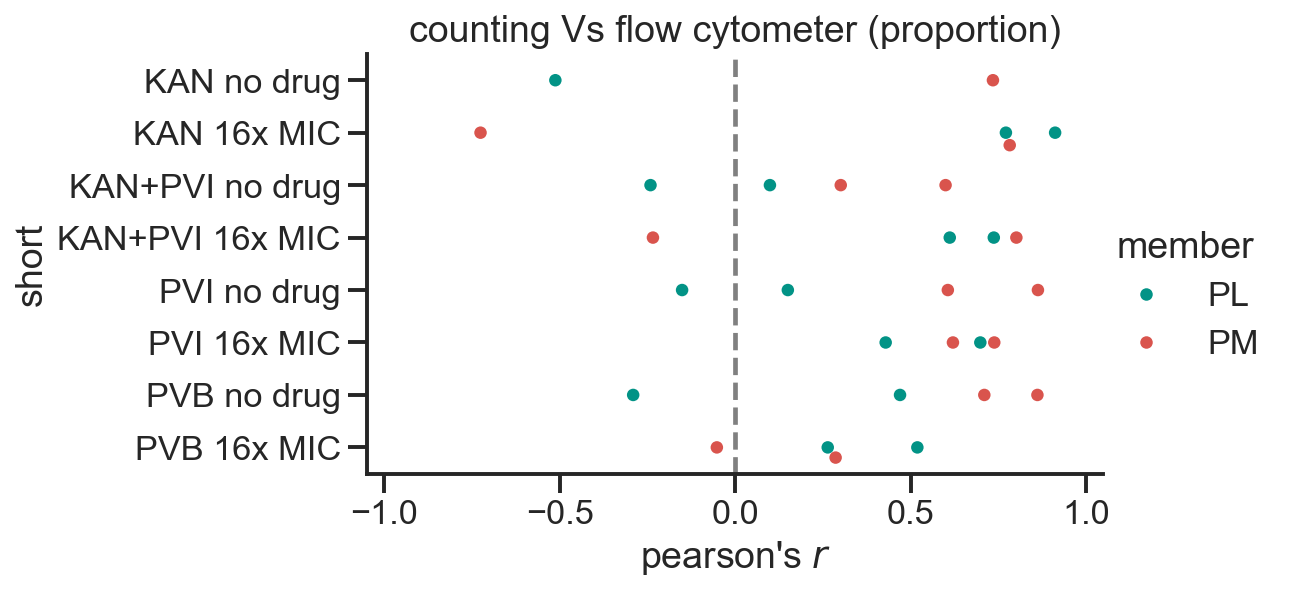

In [14]:
cp = sns.catplot(data=o,
                 hue='member',
                 kind='swarm',
                 # dodge=True,
                 palette=['xkcd:teal',
                          'xkcd:pale red'],
                 y='short',
                 x='proportion',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='counting Vs flow cytometer (proportion)',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')

In [15]:
# read chibio
m = pd.read_csv('data/pOXA48/chibio.tsv.gz', sep='\t')
# round time
m['time'] = [round(float(x), 2) for x in m['time']]
# read plate counts
c = pd.read_csv('data/pOXA48/plate_counts.tsv', sep='\t')
# round time
c['time'] = [round(float(x), 2) for x in c['time']]
# take the log of the CFU/mL
c['log_CFU/mL'] = np.log10(c['CFU/mL'])
# only KAN plates
c = c[c['plate'] == 'KAN']
# read plate reader fluorescence
p = pd.read_csv('data/pOXA48/plate_reader_fluorescence.tsv', sep='\t')
# round time
p['time'] = [round(float(x), 2) for x in p['time']]
# take the log of the emission
p['log_emission'] = np.log10(p['emission'])
# read flow cytometer
f = pd.read_csv('data/pOXA48/flow_cytometer.tsv', sep='\t')
# round time
f['time'] = [round(float(x), 2) for x in f['time']]

In [16]:
# cut data from earlier than 36 hours
# for chibio take the average over the time period
m = m[m['time'] >= 36].reset_index(drop=True)
m = m.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])[['smooth_masked_FP1_emit1', 'smooth_masked_FP2_emit1']].mean()
c = c[c['time'] >= 36].reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
p = p[p['time'] >= 36].reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
f = f[f['time'] >= 36].reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])

In [17]:
# counting vs plate reader
c = c.reset_index().set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'strain', 'time'])
p = p.reset_index()
p['strain'] = ''
p.loc[p[p['wavelength'] == '467-510'].index, 'strain'] = 'PL'
p.loc[p[p['wavelength'] == '523-620'].index, 'strain'] = 'PM'
p = p.set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'strain', 'time'])
o = c.join(p,
           how='inner').reset_index()

o = o.groupby(['vial', 'replicate', 'name', 'short',
               'plasmid', 'drug', 'strain'])[
    ['log_CFU/mL',
     'log_emission']].corr().reset_index().rename(
        columns={'level_7': 'variable'})

res = []
tmp = o[(o['strain'] == 'PL') & (o['variable'] == 'log_CFU/mL')].copy()
tmp['member'] = 'PL'
res.append(tmp)
tmp = o[(o['strain'] == 'PM') & (o['variable'] == 'log_CFU/mL')].copy()
tmp['member'] = 'PM'
res.append(tmp)
o = pd.concat(res).reset_index(drop=True)

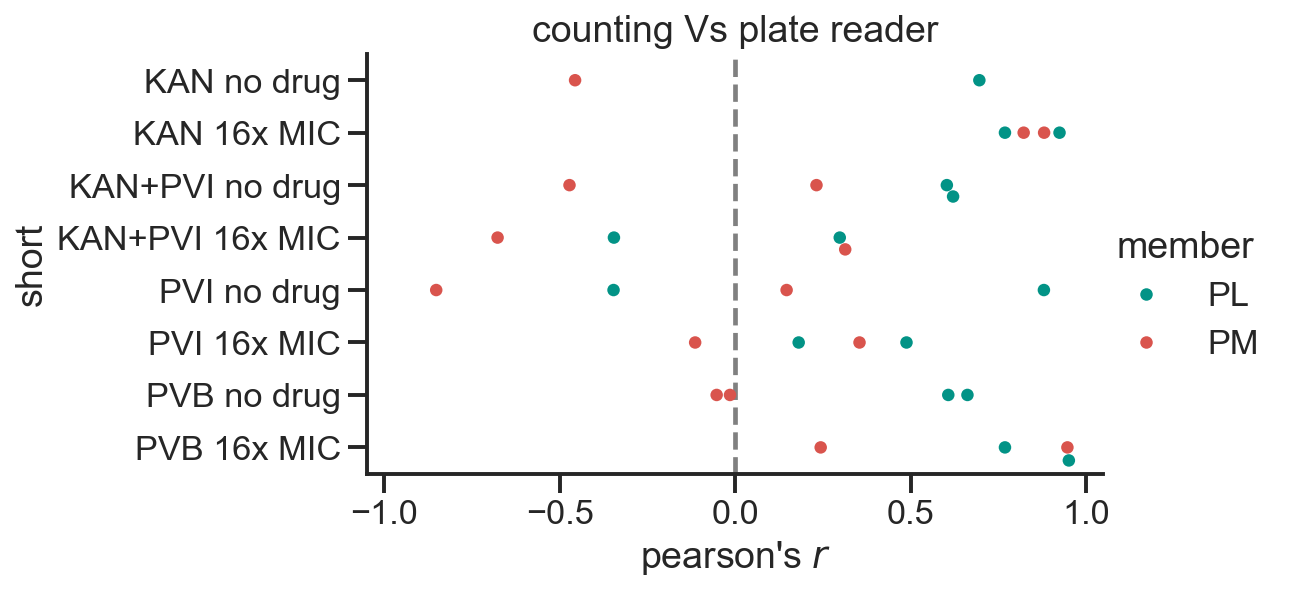

In [18]:
cp = sns.catplot(data=o,
                 hue='member',
                 kind='swarm',
                 # dodge=True,
                 palette=['xkcd:teal',
                          'xkcd:pale red'],
                 y='short',
                 x='log_emission',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='counting Vs plate reader',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')

In [19]:
# read chibio
m = pd.read_csv('data/pOXA48/chibio.tsv.gz', sep='\t')
# round time
m['time'] = [round(float(x), 2) for x in m['time']]
# read plate counts
c = pd.read_csv('data/pOXA48/plate_counts.tsv', sep='\t')
# round time
c['time'] = [round(float(x), 2) for x in c['time']]
# take the log of the CFU/mL
c['log_CFU/mL'] = np.log10(c['CFU/mL'])
# only KAN plates
c = c[c['plate'] == 'KAN']
# read plate reader fluorescence
p = pd.read_csv('data/pOXA48/plate_reader_fluorescence.tsv', sep='\t')
# round time
p['time'] = [round(float(x), 2) for x in p['time']]
# take the log of the emission
p['log_emission'] = np.log10(p['emission'])
# read flow cytometer
f = pd.read_csv('data/pOXA48/flow_cytometer.tsv', sep='\t')
# round time
f['time'] = [round(float(x), 2) for x in f['time']]

In [20]:
# for chibio take the average over the time period
m = m.reset_index(drop=True)
m = m.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])[['smooth_norm_FP1_emit1_FP2_emit1_ratio']].mean().rename(
    columns={'smooth_norm_FP1_emit1_FP2_emit1_ratio': 'chibio PL / PM'})
c = c.reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
p = p.reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
f = f.reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])

In [21]:
# prepare ratios for counting, flow and plate reader
c = c.reset_index().groupby(['vial', 'replicate', 'name',
                             'short', 'plasmid', 'drug', 'time'],
                           ).apply(lambda x:
                                   (x[x['strain'] == 'PL']['CFU/mL'].mean() / 
                                    x[x['strain'] == 'PM']['CFU/mL'].mean()) /
                                   x['CFU/mL'].sum(),
                                   include_groups=False).reset_index(
    ).rename(columns={0: 'counting PL / PM'}
            ).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])

In [22]:
p = p.reset_index().groupby(['vial', 'replicate', 'name',
                             'short', 'plasmid', 'drug', 'time'],
                           ).apply(lambda x:
                                   x[x['wavelength'] == '467-510']['emission'].mean() / 
                                   x[x['wavelength'] == '523-620']['emission'].mean(),
                                   include_groups=False).reset_index(
    ).rename(columns={0: 'plate reader PL / PM'}
            ).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])

In [23]:
f['events'] = f['events'] + 1
f = f.reset_index().groupby(['vial', 'replicate', 'name',
                             'short', 'plasmid', 'drug', 'time'],
                           ).apply(lambda x:
                                   x[x['strain'] == 'PL']['events'].mean() / 
                                   x[x['strain'] == 'PM']['events'].mean(),
                                   include_groups=False).reset_index(
    ).rename(columns={0: 'flow PL / PM'}
            ).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])

In [24]:
# chibio vs plate counting
o = m.join(c, 
           how='inner').reset_index()

o = o.groupby(['vial', 'replicate', 'name', 'short',
               'plasmid', 'drug'])[
    ['chibio PL / PM', 'counting PL / PM']].corr().reset_index().rename(
        columns={'level_6': 'variable'})

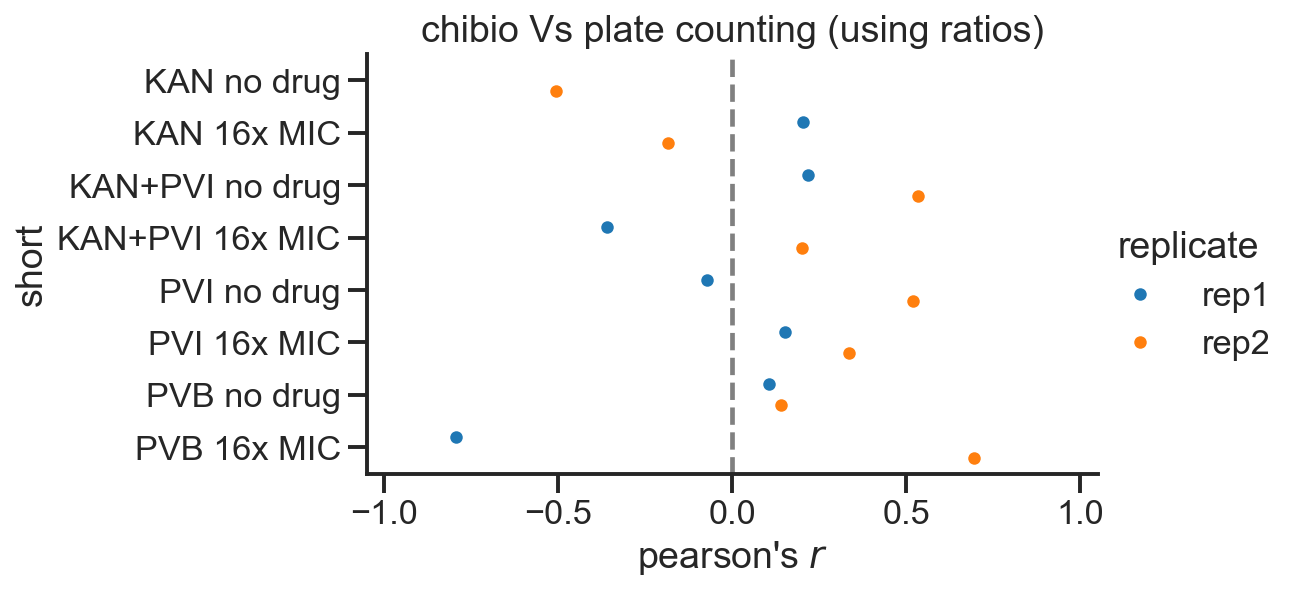

In [25]:
cp = sns.catplot(data=o[o['variable'] == 'chibio PL / PM'],
                 hue='replicate',
                 hue_order=['rep1', 'rep2'],
                 kind='swarm',
                 dodge=True,
                 # palette=['xkcd:teal',
                 #          'xkcd:pale red'],
                 y='short',
                 x='counting PL / PM',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='chibio Vs plate counting (using ratios)',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')

In [26]:
# chibio vs plate reader
o = m.join(p, 
           how='inner').reset_index()

o = o.groupby(['vial', 'replicate', 'name', 'short',
               'plasmid', 'drug'])[
    ['chibio PL / PM', 'plate reader PL / PM']].corr().reset_index().rename(
        columns={'level_6': 'variable'})

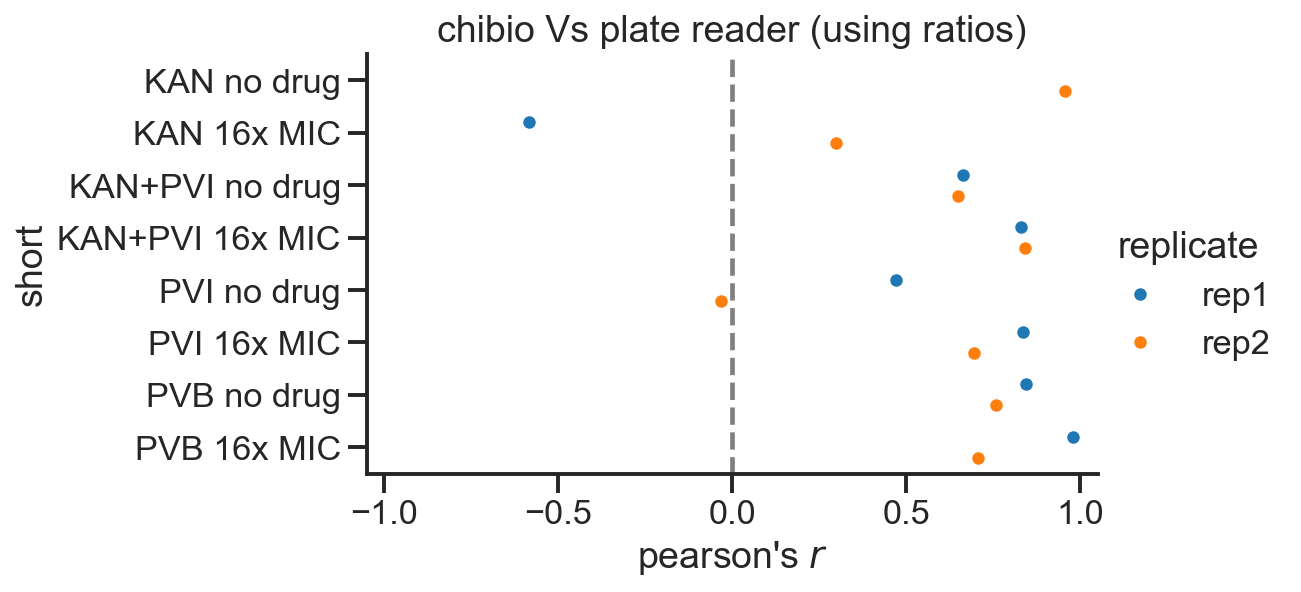

In [27]:
cp = sns.catplot(data=o[o['variable'] == 'chibio PL / PM'],
                 hue='replicate',
                 hue_order=['rep1', 'rep2'],
                 kind='swarm',
                 dodge=True,
                 # palette=['xkcd:teal',
                 #          'xkcd:pale red'],
                 y='short',
                 x='plate reader PL / PM',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='chibio Vs plate reader (using ratios)',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')

In [28]:
# chibio vs flow
o = m.join(f, 
           how='inner').reset_index()

o = o.groupby(['vial', 'replicate', 'name', 'short',
               'plasmid', 'drug'])[
    ['chibio PL / PM', 'flow PL / PM']].corr().reset_index().rename(
        columns={'level_6': 'variable'})

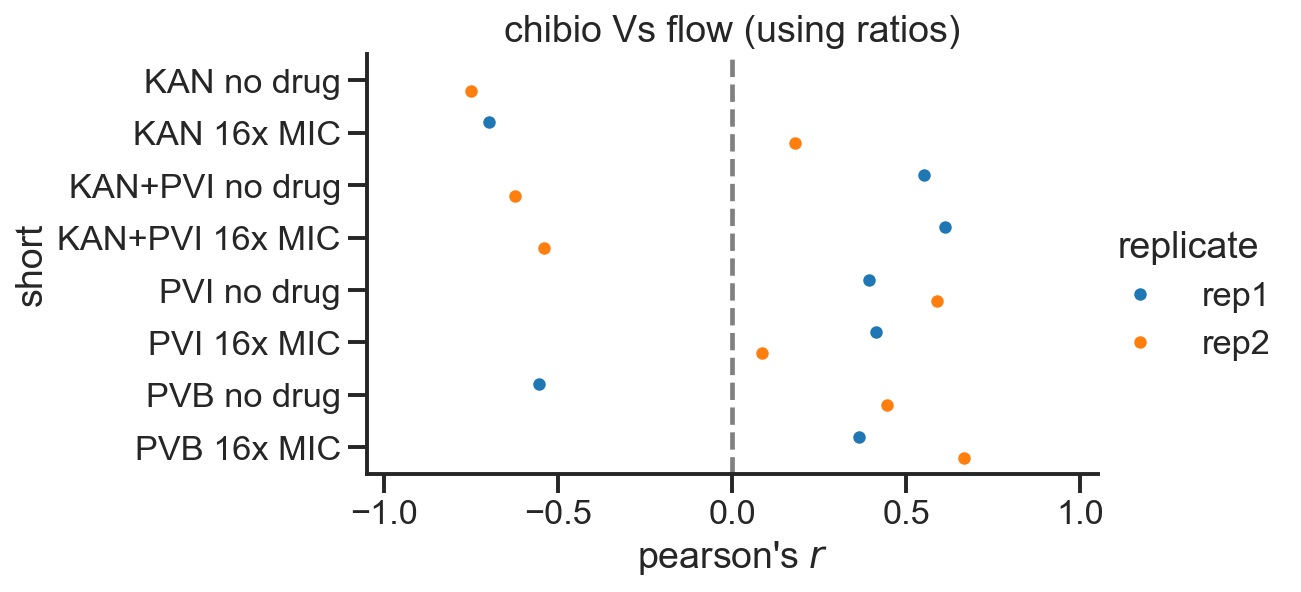

In [29]:
cp = sns.catplot(data=o[o['variable'] == 'chibio PL / PM'],
                 hue='replicate',
                 hue_order=['rep1', 'rep2'],
                 kind='swarm',
                 dodge=True,
                 # palette=['xkcd:teal',
                 #          'xkcd:pale red'],
                 y='short',
                 x='flow PL / PM',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='chibio Vs flow (using ratios)',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')

In [30]:
# read chibio
m = pd.read_csv('data/pOXA48/chibio.tsv.gz', sep='\t')
# round time
m['time'] = [round(float(x), 2) for x in m['time']]
# read plate counts
c = pd.read_csv('data/pOXA48/plate_counts.tsv', sep='\t')
# round time
c['time'] = [round(float(x), 2) for x in c['time']]
# take the log of the CFU/mL
c['log_CFU/mL'] = np.log10(c['CFU/mL'])
# only KAN plates
c = c[c['plate'] == 'KAN']
# read plate reader fluorescence
p = pd.read_csv('data/pOXA48/plate_reader_fluorescence.tsv', sep='\t')
# round time
p['time'] = [round(float(x), 2) for x in p['time']]
# take the log of the emission
p['log_emission'] = np.log10(p['emission'])
# read flow cytometer
f = pd.read_csv('data/pOXA48/flow_cytometer.tsv', sep='\t')
# round time
f['time'] = [round(float(x), 2) for x in f['time']]

In [31]:
# cut data from earlier than 36 hours
# for chibio take the average over the time period
m = m[m['time'] >= 36].reset_index(drop=True)
m = m.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])[['smooth_masked_FP1_emit1', 'smooth_masked_FP2_emit1']].mean()
c = c[c['time'] >= 36].reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
p = p[p['time'] >= 36].reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])
f = f[f['time'] >= 36].reset_index(drop=True).set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time'])

In [32]:
# counting vs plate reader
c = c.reset_index().set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'strain', 'time'])
p = p.reset_index()
p['strain'] = ''
p.loc[p[p['wavelength'] == '467-510'].index, 'strain'] = 'PL'
p.loc[p[p['wavelength'] == '523-620'].index, 'strain'] = 'PM'
p = p.set_index(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'strain', 'time'])
o = c.join(p,
           how='inner').reset_index()

o = o.groupby(['vial', 'replicate', 'name', 'short',
               'plasmid', 'drug', 'strain'])[
    ['log_CFU/mL',
     'log_emission']].corr().reset_index().rename(
        columns={'level_7': 'variable'})

res = []
tmp = o[(o['strain'] == 'PL') & (o['variable'] == 'log_CFU/mL')].copy()
tmp['member'] = 'PL'
res.append(tmp)
tmp = o[(o['strain'] == 'PM') & (o['variable'] == 'log_CFU/mL')].copy()
tmp['member'] = 'PM'
res.append(tmp)
o = pd.concat(res).reset_index(drop=True)

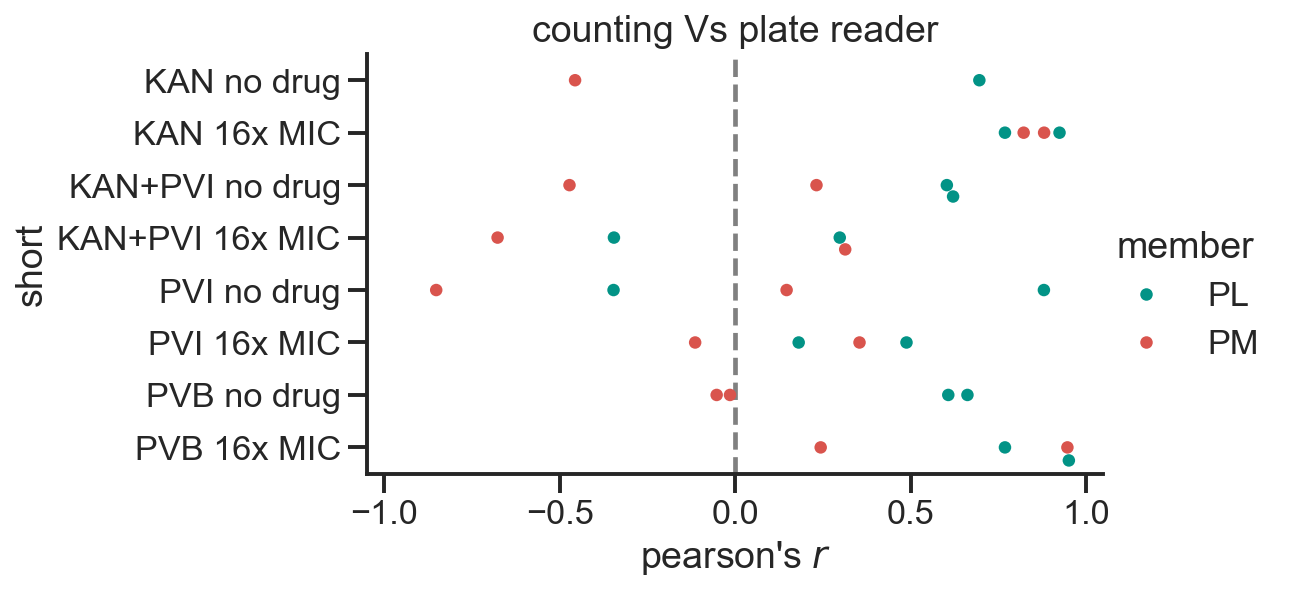

In [33]:
cp = sns.catplot(data=o,
                 hue='member',
                 kind='swarm',
                 # dodge=True,
                 palette=['xkcd:teal',
                          'xkcd:pale red'],
                 y='short',
                 x='log_emission',
                 height=4, aspect=2,
                 size=6)

cp.set(xlabel='pearson\'s $r$',
       title='counting Vs plate reader',
       xlim=(-1.05, 1.05))

for ax in cp.axes.flatten():
    ax.axvline(0, color='grey', ls='dashed')